<a href="https://colab.research.google.com/github/CMILINAZZO/medical-llm-self-bias-audit/blob/main/notebooks/04_analysis_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import os
import shutil
from pathlib import Path
import pandas as pd
from google.colab import userdata

# 1. Configuration
GITHUB_USERNAME = "CMILINAZZO"
REPO_NAME = "medical-llm-self-bias-audit"
REPO_ROOT = Path(f"/content/{REPO_NAME}")

# 2. Clean clone sequence
if REPO_ROOT.exists() and not (REPO_ROOT / ".git").exists():
    shutil.rmtree(REPO_ROOT)

if not REPO_ROOT.exists():
    print("Cloning fresh copy of the repository...")
    !git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
else:
    print("Repository found. Pulling latest updates...")
    os.chdir(REPO_ROOT)
    !git pull

# 3. Synchronize Working Directory
os.chdir(REPO_ROOT / "notebooks")
print(f"\\n Active Working Directory synchronized to: {os.getcwd()}")

Cloning fresh copy of the repository...
Cloning into 'medical-llm-self-bias-audit'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 176 (delta 114), reused 9 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 659.45 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (114/114), done.
\n Active Working Directory synchronized to: /content/medical-llm-self-bias-audit/notebooks


In [2]:
# Cell 2: Load & Clean the Data

# 1. Define standard paths
OUTPUT_PATH = "../outputs/final_audit_matrix.csv"

# 2. Load the matrix
df_audit = pd.read_csv(OUTPUT_PATH)

# 3. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_audit['judge_model'] = df_audit['judge_model'].apply(clean_judge_name)

print(f" Data loaded and cleaned! Total evaluations: {len(df_audit)}")
print("\\nJudge Distribution:")
print(df_audit['judge_model'].value_counts())

 Data loaded and cleaned! Total evaluations: 507
\nJudge Distribution:
judge_model
gpt-4o               250
claude-sonnet-4-6    170
gemini-2.5-pro        87
Name: count, dtype: int64


**IMPORTANT NOTE:** The following Cell 3 only needs to be run if you had to run cells 7-8 in Notebook 3.

In [4]:
# Cell 3: Load & Clean the Data

# 1. Load both files
df_salvaged = pd.read_csv('../outputs/salvaged_audit_matrix.csv')
df_final = pd.read_csv('../outputs/final_audit_matrix.csv')

# 2. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_salvaged['judge_model'] = df_salvaged['judge_model'].apply(clean_judge_name)
df_final['judge_model'] = df_final['judge_model'].apply(clean_judge_name)

# 3. Combine, prioritize the final matrix (since it has ROUGE-L), and drop duplicates
df_combined = pd.concat([df_final, df_salvaged], ignore_index=True)
df_master = df_combined.drop_duplicates(subset=['pmid', 'student_model', 'judge_model'], keep='first')

print(f"Yay! Total unique evaluations squeezed out: {len(df_master)}")
print("\nFinal Judge Distribution:")
print(df_master['judge_model'].value_counts())

Yay! Total unique evaluations squeezed out: 571

Final Judge Distribution:
judge_model
gpt-4o               299
claude-sonnet-4-6    170
gemini-2.5-pro       102
Name: count, dtype: int64


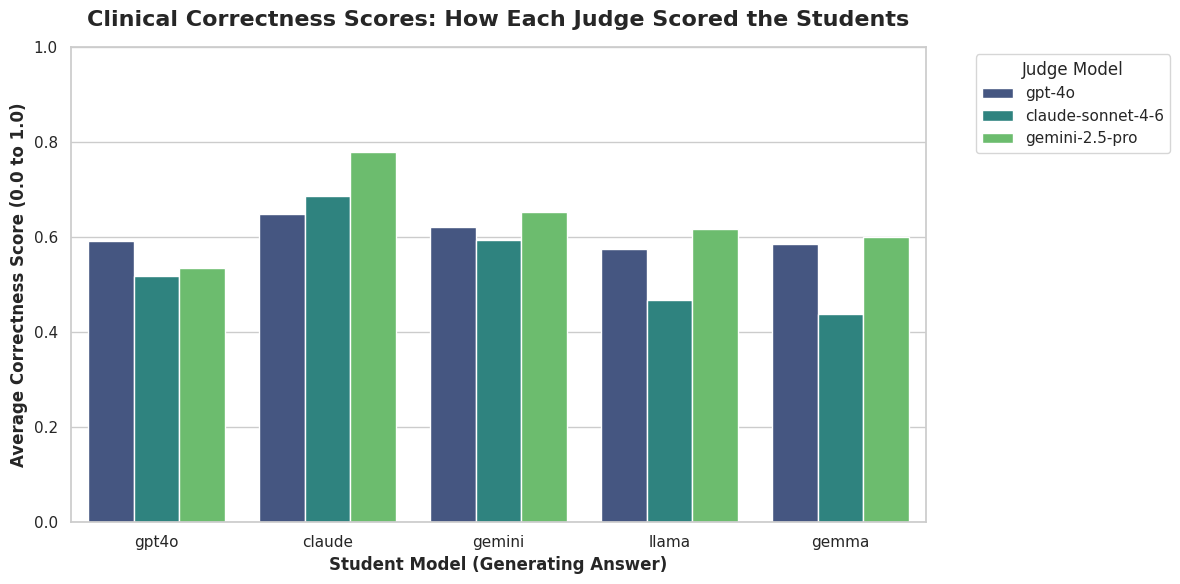

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 4: Correctness by Judge - Grouped Bar Chart

# Set the visual style for the charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a grouped bar chart
ax = sns.barplot(
    data=df_master,
    x='student_model',
    y='correctness_score',
    hue='judge_model',
    palette='viridis',
    errorbar=None # Turns off the confidence interval lines for a cleaner look
)

# Formatting the chart
plt.title('Clinical Correctness Scores: How Each Judge Scored the Students', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Student Model (Generating Answer)', fontsize=12, fontweight='bold')
plt.ylabel('Average Correctness Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0) # Lock the y-axis to a 0-1 scale
plt.legend(title='Judge Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the chart
plt.show()

**Observations on Correctness:**  
* claude as a judge:
  * Very punitive towards the local models (gemma & llama)
  * Prefers its own responses above the others, but maybe not unjustly - all judges rated claude the highest
* gemini as a judge:
  * Most lenient judge overall, *except* with gpt4o
  * Prefers its own responses to a degree, but it's unclear if this is self bias, or just a more positive rating tendency overall
* gpt4o as a judge:
  * Rating averages are all just below or just above 0.6
  * Prefers its responses more than the other 2 judges, which suggests self preference to me

Claude performed the best, according to all 3 judges. The judges were most aligned on Gemini's performance.

In [6]:
# Cell 4: Neatly Formatted Score Averages Table
import pandas as pd

# 1. Calculate average Correctness scores by Student and Judge
pivot_correctness = df_master.pivot_table(
    index='student_model',
    columns='judge_model',
    values='correctness_score',
    aggfunc='mean'
)

# 2. Calculate average Faithfulness scores by Student and Judge
pivot_faithfulness = df_master.pivot_table(
    index='student_model',
    columns='judge_model',
    values='faithfulness_score',
    aggfunc='mean'
)

# 3. Rename columns for clean presentation
column_mapping = {
    'claude-sonnet-4-6': 'Claude Judge (Avg)',
    'gemini-2.5-pro': 'Gemini Judge (Avg)',
    'gpt-4o': 'GPT-4o Judge (Avg)'
}

pivot_correctness = pivot_correctness.rename(columns=column_mapping)
pivot_faithfulness = pivot_faithfulness.rename(columns=column_mapping)

# 4. Display the Correctness Matrix with formatting
print("="*60)
print("             CLINICAL CORRECTNESS MATRIX")
print("="*60)
display(pivot_correctness.style.format("{:.3f}").background_gradient(cmap='Blues', axis=None))

print("\n" + "="*60)
print("             FACTUAL FAITHFULNESS MATRIX")
print("="*60)
display(pivot_faithfulness.style.format("{:.3f}").background_gradient(cmap='Greens', axis=None))

             CLINICAL CORRECTNESS MATRIX


judge_model,Claude Judge (Avg),Gemini Judge (Avg),GPT-4o Judge (Avg)
student_model,,,
claude,0.685,0.779,0.647
gemini,0.594,0.653,0.621
gemma,0.438,0.600,0.584
gpt4o,0.518,0.535,0.592
llama,0.468,0.617,0.574



             FACTUAL FAITHFULNESS MATRIX


judge_model,Claude Judge (Avg),Gemini Judge (Avg),GPT-4o Judge (Avg)
student_model,,,
claude,0.973,0.994,0.957
gemini,0.969,0.986,0.948
gemma,0.910,0.873,0.898
gpt4o,0.969,0.974,0.961
llama,0.962,0.948,0.937


At this point, it is worth noting that when you have missing observations across different groups (in this case, GPT-4o graded 50 questions, Claude graded ~34, and Gemini graded ~20), directly comparing their overall averages introduces Row-Level Difficulty. To eliminate this confounding variable, we will use an Intersection Analysis (or Paired/Repeated Measures Framework). We filter the dataset down to only the specific rows (PMIDs) that were successfully graded by all three judges.

INTERSECTION ANALYSIS (28 Common Clinical Questions)


judge_model,claude-sonnet-4-6,gemini-2.5-pro,gpt-4o
student_model,,,
claude,0.643,0.788,0.641
gemini,0.596,0.707,0.625
gemma,0.454,0.650,0.582
gpt4o,0.518,0.547,0.576
llama,0.461,0.567,0.558


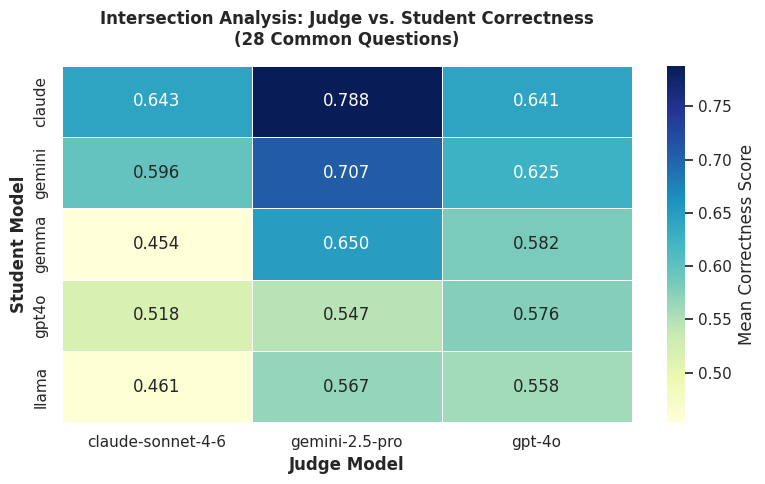

In [11]:
import pandas as pd

# 1. Load both files from the outputs directory
df_salvaged = pd.read_csv('../outputs/salvaged_audit_matrix.csv')
df_final = pd.read_csv('../outputs/final_audit_matrix.csv')

# 2. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_salvaged['judge_model'] = df_salvaged['judge_model'].apply(clean_judge_name)
df_final['judge_model'] = df_final['judge_model'].apply(clean_judge_name)

# 3. Combine, prioritize the final matrix (since it has ROUGE-L), and drop duplicates
df_combined = pd.concat([df_final, df_salvaged], ignore_index=True)
df_master = df_combined.drop_duplicates(subset=['pmid', 'student_model', 'judge_model'], keep='first')

# 4. Filter down to the intersection (PMIDs evaluated by ALL THREE judges)
pmid_judge_counts = df_master.groupby('pmid')['judge_model'].nunique()
common_pmids = pmid_judge_counts[pmid_judge_counts == 3].index.tolist()

df_intersection = df_master[df_master['pmid'].isin(common_pmids)]

# 5. Build the perfectly balanced Pivot Table
pivot_intersection = df_intersection.pivot_table(
    index='student_model',
    columns='judge_model',
    values='correctness_score',
    aggfunc='mean'
)

print("="*60)
print(f"INTERSECTION ANALYSIS ({len(common_pmids)} Common Clinical Questions)")
print("="*60)

# Render a clean HTML table instead of plain text
display(pivot_intersection.style.format("{:.3f}").background_gradient(cmap='Blues', axis=1))

# 6. Generate the Heatmap Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_intersection,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Mean Correctness Score'},
    linewidths=0.5
)

plt.title(f"Intersection Analysis: Judge vs. Student Correctness\n({len(common_pmids)} Common Questions)", pad=15, fontweight='bold')
plt.ylabel("Student Model", fontweight='bold')
plt.xlabel("Judge Model", fontweight='bold')
plt.tight_layout()

# Show the chart
plt.show()